# Activation Functions

Activation functions bring **non-linearity** to neural networks.

Different activation functions would have different effects on deep learning models. So choose carefully.

In [3]:
# --- Standard libraries ---
import os
import json
import math
import numpy as np

# --- For plotting ---
import matplotlib.pyplot as plt
%matplotlib inline
import IPython.display
from matplotlib_inline.backend_inline import set_matplotlib_formats
IPython.display.set_matplotlib_formats = set_matplotlib_formats
set_matplotlib_formats('svg', 'pdf') # for export
import seaborn as sns
sns.set()

# --- Progress bar ---
from tqdm.notebook import tqdm

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

Define a function to **set the seed** for all libraries used in this notebook for **reproducibility**.

Additionally, define two **static variables** to store the **data** and the saved **model** paths. 

It is **recommended** to store **all the datasets** from Pytorch in **one joint directory** to prevent duplicate downloads.

In [4]:
# Set the path for dataset
DATASET_PATH = './data'
# Set the path for saved model weights
CHECKPOINT_PATH = './saved_models'

# Seed function for numpy, pytorch
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
        torch.use_deterministic_algorithms(True)

set_seed(42)

# Set the device
device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
print("Device", device)

Device mps


In [5]:
import urllib.request
from urllib.error import HTTPError
base_url = "https://raw.githubusercontent.com/phlippe/saved_models/main/tutorial3/"
pretrained_files = ["FashionMNIST_elu.config", "FashionMNIST_elu.tar",
                    "FashionMNIST_leakyrelu.config", "FashionMNIST_leakyrelu.tar",
                    "FashionMNIST_relu.config", "FashionMNIST_relu.tar",
                    "FashionMNIST_sigmoid.config", "FashionMNIST_sigmoid.tar",
                    "FashionMNIST_swish.config", "FashionMNIST_swish.tar",
                    "FashionMNIST_tanh.config", "FashionMNIST_tanh.tar"]

os.makedirs(CHECKPOINT_PATH, exist_ok=True)

for file_name in pretrained_files:
    file_path = os.path.join(CHECKPOINT_PATH, file_name)
    if not os.path.isfile(file_path):
        file_url = base_url + file_name
        print(f"Downloading {file_url} ...")
        try:
            urllib.request.urlretrieve(file_url, file_path)
        except HTTPError as e:
            print(f"Failed to download {file_url}. Error: {e}")

## Common activation functions

Most of the **activation functions** could be found in the **`torch.nn`** package.

Define a base class that inherits from **`nn.Module`** so that we can integrate them nicely into the network. We will use the `config` directory to store adjustable parameters for some activation functions.


In [6]:
class ActivationFunction(nn.Module):
    def __init__(self):
        super().__init__()
        self.name = self.__class__.__name__
        self.config = {"name": self.name}

The oldest two are **`Sigmoid`** and **`Tanh`**, which are still used in some tasks.

They can be found in `torch.sigmoid` and `torch.tanh` or as modules(`nn.Sigmoid`, `nn.Tanh`).

In [7]:
# Sigmoid
class Sigmoid(ActivationFunction):
    def forward(self, x):
        return 1 / (1 + torch.exp(-x))

# Tanh
class Tanh(ActivationFunction):
    def forward(self, x):
        x_exp, neg_x_exp = torch.exp(x), torch.exp(-x)
        return (x_exp - neg_x_exp) / (x_exp + neg_x_exp)

Another popular one is **Rectified Linear Unit(ReLU)**, which allows **training deep** neural networks.

Despite its simplicity of being a [piecewise linear function](https://en.wikipedia.org/wiki/Piecewise_linear_function), ReLU has a **strong, stable gradient for a large range of input values** compared to sigmoid and tanh. Based on this idea, a lot of "ReLU"-like functions were proposed, such as LeakyReLU, ELU, and Swish.
* **LeakyReLU**: replaces the zero settings in the negative part with a smaller slope to allow gradients to flow also in this part of the input.
* **ELU**: replaces the negative part with an exponential decay.
* **Swish**: is both **smooth** and **non-monotonic**, which **prevents dead neurons** as in standard ReLU. See [Searching for Activation Functions](https://arxiv.org/abs/1710.05941).


In [8]:
# --- ReLU-based ---

# ReLU
class ReLU(ActivationFunction):
    def forward(self, x):
        return x * (x > 0).float()

# LeakyReLU
class LeakyReLU(ActivationFunction):
    def __init__(self, alpha=0.1):
        super().__init__()
        self.config['alpha'] = alpha

    def forward(self, x):
        return torch.where(x > 0, x, self.config['alpha'] * x)

# ELU
class ELU(ActivationFunction):
    def forward(self, x):
        return torch.where(x > 0, x, torch.exp(x)-1)

# Swish
class Swish(ActivationFunction):
    def forward(self, x):
        return x * torch.sigmoid(x)

In [9]:
act_fn_by_name = {
    "sigmoid": Sigmoid,
    "tanh": Tanh,
    "relu": ReLU,
    "leakyrelu": LeakyReLU,
    "elu": ELU,
    "swish": Swish,
}

## Visualizing activation functions

In [10]:
def get_grads(act_fn, x):
    """
    Computes the gradients of an activation function at specified positions.
    
    Args:
        act_fn: The activation function to compute gradients for.
        x: The input tensor for which to compute gradients.
        
    Returns:
        The gradients of the activation function at the specified positions.
    """
    # Mark the input as tensor for which we want to store gradients.
    x = x.clone().requires_grad_()
    out = act_fn(x)
    # Summing results in an equal gradient flow to each element in x
    out.sum().backward()
    # Accessing the gradients of x by "x.grad"
    return x.grad

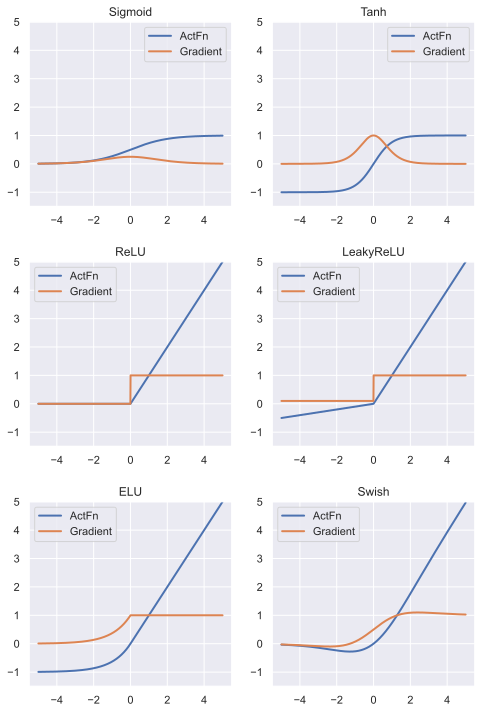

In [11]:
def vis_act_fn(act_fn, ax, x):
    # Run activation function
    y = act_fn(x)
    y_grads = get_grads(act_fn, x)
    # Push x, y and gradients back to cpu for plotting
    x, y, y_grads = x.cpu().numpy(), y.cpu().numpy(), y_grads.cpu().numpy()
    ## Plotting
    ax.plot(x, y, linewidth=2, label="ActFn")
    ax.plot(x, y_grads, linewidth=2, label="Gradient")
    ax.set_title(act_fn.name)
    ax.legend()
    ax.set_ylim(-1.5, x.max())

# Add activation functions if wanted
act_fns = [act_fn() for act_fn in act_fn_by_name.values()]
# Range on which we want to visualize the activation functions
x = torch.linspace(-5, 5, 1000)
## Plotting
rows = math.ceil(len(act_fns)/2.0)
fig, ax = plt.subplots(rows, 2, figsize=(8, rows*4))
for i, act_fn in enumerate(act_fns):
    vis_act_fn(act_fn, ax[divmod(i,2)], x)
fig.subplots_adjust(hspace=0.3)
plt.show()

## Analysing the effect of activation functions

### Setup

First, building a neural network which views the images as 1D tensors and pushes them through a sequence of linear layers and a specific activation function.


In [23]:
class BaseNetwork(nn.Module):
    def __init__(self, act_fn, input_size=784, num_classes=10, hidden_sizes=[512, 256, 256, 128]):
        super().__init__()

        # Create the network based on the specified hidden sizes
        layers = []
        layer_sizes = [input_size] + hidden_sizes
        for layer_index in range(1, len(layer_sizes)):
            layers += [nn.Linear(layer_sizes[layer_index-1], layer_sizes[layer_index]),
                       act_fn]
        layers += [nn.Linear(layer_sizes[-1], num_classes)]
        # `nn.Sequential` summarizes a list of modules into a single module, applying them in sequence
        self.layers = nn.Sequential(*layers)

        # We store all hyperparameters in a dictionary for saving and loading of the model
        self.config = {"act_fn": act_fn.config, "input_size": input_size, "num_classes": num_classes, "hidden_sizes": hidden_sizes}

    def forward(self, x):
        # Reshape images to a flat vector
        x = x.view(x.size(0), -1)
        out = self.layers(x)
        return out

Also set up the helper functions for loading and storing the model weights.

In [ ]:
def _get_config_file(model_path, model_name):
    # Name of the file for storing hyperparameter details
    return os.path.join(model_path, model_name + ".config")

def _get_model_file(model_path, model_name):
    # Name of the file for storing network parameters
    return os.path.join(model_path, model_name + ".tar")

def load_model(model_path, model_name, net=None):
    config_file, model_file = _get_config_file(model_path, model_name), _get_model_file(model_path, model_name)
    assert os.path.isfile(config_file), f"Could not find the config file \"{config_file}\". Are you sure this is the correct path and you have your model config stored here?"
    assert os.path.isfile(model_file), f"Could not find the model file \"{model_file}\". Are you sure this is the correct path and you have your model stored here?"
    with open(config_file, "r") as f:
        config_dict = json.load(f)
    if net is None:
        act_fn_name = config_dict["act_fn"].pop("name").lower()
        act_fn = act_fn_by_name[act_fn_name](**config_dict.pop("act_fn"))
        net = BaseNetwork(act_fn=act_fn, **config_dict)
    net.load_state_dict(torch.load(model_file, map_location=device))
    return net

def save_model(model, model_path, model_name):
    config_dict = model.config
    os.makedirs(model_path, exist_ok=True)
    config_file, model_file = _get_config_file(model_path, model_name), _get_model_file(model_path, model_name)
    with open(config_file, "w") as f:
        json.dump(config_dict, f)
    torch.save(model.state_dict(), model_file)

We would use the FashionMNIST dataset and `torchvision` to handle the data loading and preprocessing.

`torchvision` provides popular datasets, model architectures, and preprocessing transforms for computer vision tasks.

In [14]:
import torchvision
from torchvision.datasets import FashionMNIST
from torchvision import transforms

transform = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize((0.5,), (0.5,))
])

train_dataset = FashionMNIST(root=DATASET_PATH, train=True, transform=transform, download=True)
train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])
test_set = FashionMNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

train_loader = data.DataLoader(train_set, batch_size=1024, shuffle=True, drop_last=False)
val_loader = data.DataLoader(val_set, batch_size=1024, shuffle=False, drop_last=False)
test_loader = data.DataLoader(test_set, batch_size=1024, shuffle=False, drop_last=False)

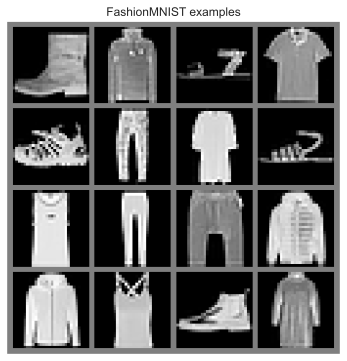

In [15]:
exmp_imgs = [train_set[i][0] for i in range(16)]
img_grid = torchvision.utils.make_grid(torch.stack(exmp_imgs, dim=0), nrow=4, normalize=True, pad_value=0.5)
img_grid = img_grid.permute(1, 2, 0)

plt.figure(figsize=(6,6))
plt.title("FashionMNIST examples")
plt.imshow(img_grid)
plt.axis("off")
plt.show()
plt.close()

### Visualizing the gradient flow

One important aspect of activation functions is how they **propagate the gradients** through the network. For a deep neural network:
* If the gradient is considerably **smaller than 1**, the gradients will **vanish** as they are multiplied layer by layer.
* If the gradient is **larger than 1**, the gradients will exponentially increase and might **explode**.

In [16]:
def visualize_gradients(net, color="C0"):
    """
    Inputs:
        net - Object of class BaseNetwork
        color - Color in which we want to visualize the histogram (for easier separation of activation functions)
    """
    net.eval()
    small_loader = data.DataLoader(train_set, batch_size=256, shuffle=False)
    imgs, labels = next(iter(small_loader))
    imgs, labels = imgs.to(device), labels.to(device)

    # Pass one batch through the network, and calculate the gradients for the weights
    net.zero_grad()
    preds = net(imgs)
    loss = F.cross_entropy(preds, labels)
    loss.backward()
    # We limit our visualization to the weight parameters and exclude the bias to reduce the number of plots
    grads = {name: params.grad.data.view(-1).cpu().clone().numpy() for name, params in net.named_parameters() if "weight" in name}
    net.zero_grad()

    ## Plotting
    columns = len(grads)
    fig, ax = plt.subplots(1, columns, figsize=(columns*3.5, 2.5))
    fig_index = 0
    for key in grads:
        key_ax = ax[fig_index%columns]
        sns.histplot(data=grads[key], bins=30, ax=key_ax, color=color, kde=True)
        key_ax.set_title(str(key))
        key_ax.set_xlabel("Grad magnitude")
        fig_index += 1
    fig.suptitle(f"Gradient magnitude distribution for activation function {net.config['act_fn']['name']}", fontsize=14, y=1.05)
    fig.subplots_adjust(wspace=0.45)
    plt.show()
    plt.close()

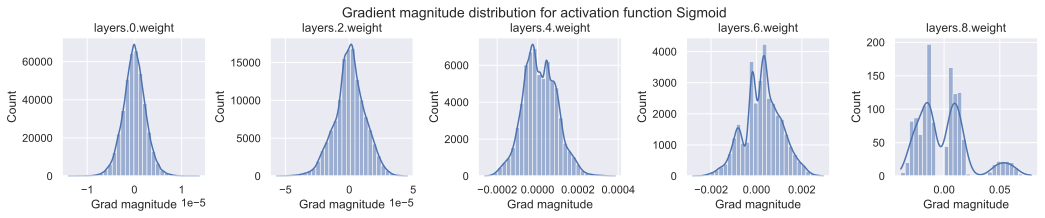

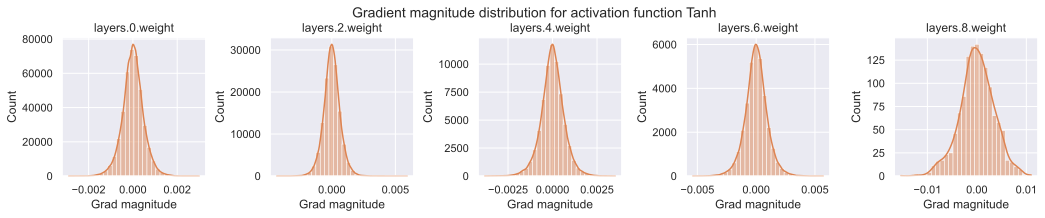

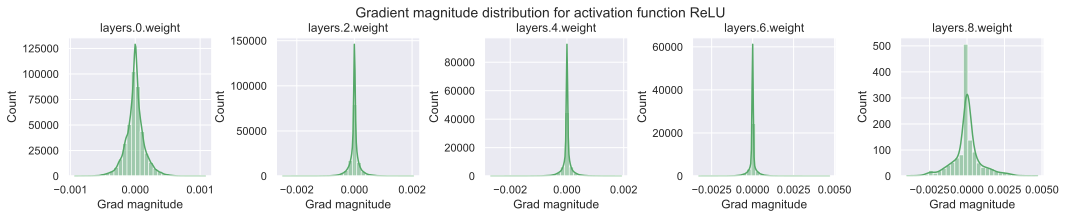

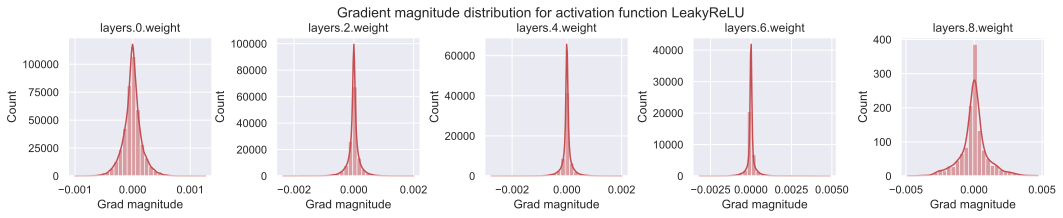

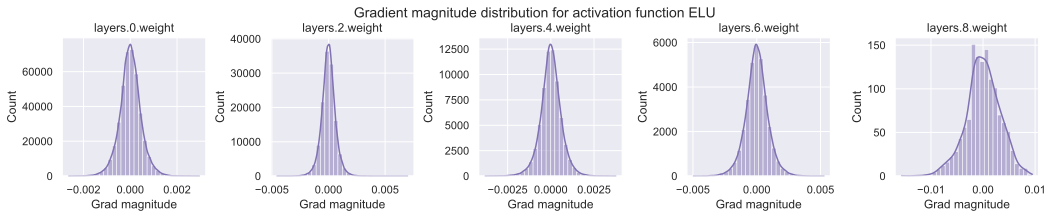

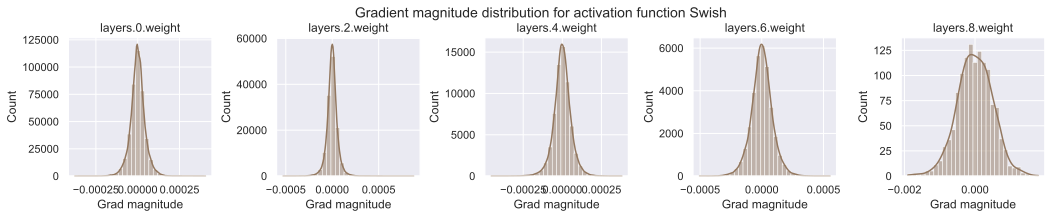

In [17]:
# Seaborn prints warnings if histogram has small values. We can ignore them for now
import warnings
warnings.filterwarnings('ignore')
## Create a plot for every activation function
for i, act_fn_name in enumerate(act_fn_by_name):
    set_seed(42) # Setting the seed ensures that we have the same weight initialization for each activation function
    act_fn = act_fn_by_name[act_fn_name]()
    net_actfn = BaseNetwork(act_fn=act_fn).to(device)
    visualize_gradients(net_actfn, color=f"C{i}")

For sigmoid, while the gradients for the output layer are very large with up to 0.1, the input layer has the lowest gradient norm across all activation functions, with only 1e-5. This is due to its small maximum gradient of 1/4, and finding a suitable learning rate across all layers is challenging. 

The ReLU has a spike around 0, which is caused by its zero-part on the left and dead neurons.

The **initialization** of weight parameters is also crucial. By default, PyTorch uses the [Kaiming initialization](https://docs.pytorch.org/docs/stable/nn.init.html#torch.nn.init.kaiming_uniform_) for **linear layers** optimized for ReLU activations.

### Training a model

In [ ]:
def train_model(net, model_name, max_epochs=50, patience=7, batch_size=256, overwrite=False):
    file_exists = os.path.isfile(_get_model_file(CHECKPOINT_PATH, model_name))
    if file_exists and not overwrite:
        print("Model file already exists. Skipping training...")
    else:
        if file_exists:
            print("Model file exists, but will be overwritten...")

        # Defining optimizer, loss and data loader
        optimizer = optim.SGD(net.parameters(), lr=1e-2, momentum=0.9)
        loss_module = nn.CrossEntropyLoss()
        train_loader_local = data.DataLoader(train_set, batch_size=batch_size, shuffle=True, drop_last=True, pin_memory=True)

        val_scores = []
        best_val_epoch = -1
        for epoch in range(max_epochs):
            # --- Training ---
            net.train()
            true_preds, count = 0., 0
            for imgs, labels in tqdm(train_loader_local, desc=f"Epoch {epoch+1}", leave=False):
                imgs, labels = imgs.to(device), labels.to(device)
                # Zero-grad can be placed anywhere before "loss.backward()"
                optimizer.zero_grad() 
                preds = net(imgs)
                loss = loss_module(preds, labels)
                loss.backward()
                optimizer.step()
                # Record statistics during training
                true_preds += (preds.argmax(dim=-1) == labels).sum()
                count += labels.shape[0]
            train_acc = true_preds / count

            # --- Validation ---
            val_acc = test_model(net, val_loader)
            val_scores.append(val_acc)
            print(f"[Epoch {epoch+1:2d}] Training accuracy: {train_acc*100.0:05.2f}%, Validation accuracy: {val_acc*100.0:05.2f}%")

            if len(val_scores) == 1 or val_acc > val_scores[best_val_epoch]:
                print("\t   (New best performance, saving model...)")
                save_model(net, CHECKPOINT_PATH, model_name)
                best_val_epoch = epoch
            elif best_val_epoch <= epoch - patience:
                print(f"Early stopping due to no improvement over the last {patience} epochs")
                break

        # Plot a curve of the validation accuracy
        plt.plot([i for i in range(1, len(val_scores)+1)], val_scores)
        plt.xlabel("Epochs")
        plt.ylabel("Validation accuracy")
        plt.title(f"Validation performance of {model_name}")
        plt.show()
        plt.close()

    load_model(CHECKPOINT_PATH, model_name, net=net)
    test_acc = test_model(net, test_loader)
    print((f" Test accuracy: {test_acc*100.0:4.2f}% ").center(50, "=")+"\n")
    return test_acc


def test_model(net, data_loader):
    net.eval()
    true_preds, count = 0., 0
    for imgs, labels in data_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.no_grad():
            preds = net(imgs).argmax(dim=-1)
            true_preds += (preds == labels).sum().item()
            count += labels.shape[0]
    test_acc = true_preds / count
    return test_acc

In [19]:
for act_fn_name in act_fn_by_name:
    print(f"Training BaseNetwork with {act_fn_name} activation...")
    set_seed(42)
    act_fn = act_fn_by_name[act_fn_name]()
    net_actfn = BaseNetwork(act_fn=act_fn).to(device)
    train_model(net_actfn, f"FashionMNIST_{act_fn_name}", overwrite=False)

Training BaseNetwork with sigmoid activation...
Model file already exists. Skipping training...
============= Test accuracy: 10.00% ==============

Training BaseNetwork with tanh activation...
Model file already exists. Skipping training...
============= Test accuracy: 87.59% ==============

Training BaseNetwork with relu activation...
Model file already exists. Skipping training...
============= Test accuracy: 88.62% ==============

Training BaseNetwork with leakyrelu activation...
Model file already exists. Skipping training...
============= Test accuracy: 88.92% ==============

Training BaseNetwork with elu activation...
Model file already exists. Skipping training...
============= Test accuracy: 87.27% ==============

Training BaseNetwork with swish activation...
Model file already exists. Skipping training...
============= Test accuracy: 88.73% ==============



The model with the **sigmoid activation fails**, which is not surprising.

All other functions perform similarly. To get a more accurate conclusion, we might need to perform a **grid search** to train the models for multiple seeds and look at the averages.

The **"optimal"** activation function **depends on many factors**, such as hidden size, number of layers, type of layers, dataset, optimizer, learning rate, etc.

In general, **all the ReLU-based activation functions perform well**, with small gains for specific activation functions in specific networks.


### Visualizing the activation distribution

In [20]:
def visualize_activations(net, color="C0"):
    activations = {}

    net.eval()
    small_loader = data.DataLoader(train_set, batch_size=1024)
    imgs, labels = next(iter(small_loader))
    with torch.no_grad():
        layer_index = 0
        imgs = imgs.to(device)
        imgs = imgs.view(imgs.size(0), -1)
        # We need to manually loop through the layers to save all activations
        for layer_index, layer in enumerate(net.layers[:-1]):
            imgs = layer(imgs)
            activations[layer_index] = imgs.view(-1).cpu().numpy()

    ## Plotting
    columns = 4
    rows = math.ceil(len(activations)/columns)
    fig, ax = plt.subplots(rows, columns, figsize=(columns*2.7, rows*2.5))
    fig_index = 0
    for key in activations:
        key_ax = ax[fig_index//columns][fig_index%columns]
        sns.histplot(data=activations[key], bins=50, ax=key_ax, color=color, kde=True, stat="density")
        key_ax.set_title(f"Layer {key} - {net.layers[key].__class__.__name__}")
        fig_index += 1
    fig.suptitle(f"Activation distribution for activation function {net.config['act_fn']['name']}", fontsize=14)
    fig.subplots_adjust(hspace=0.4, wspace=0.4)
    plt.show()
    plt.close()

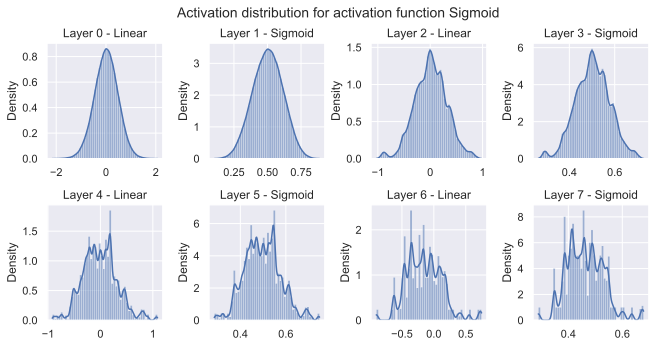

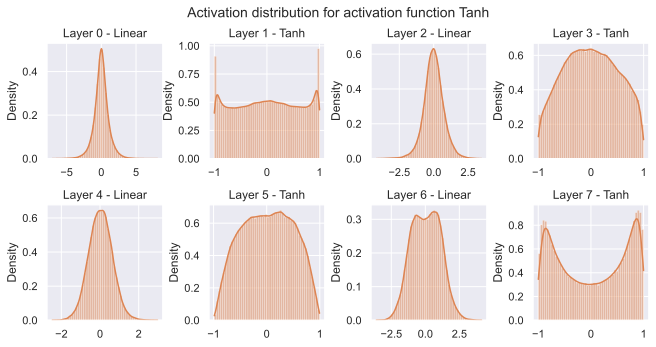

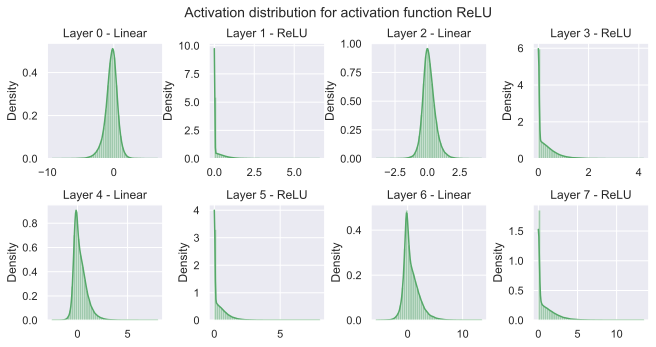

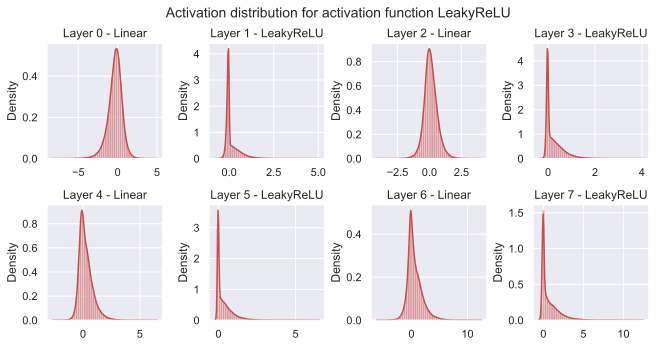

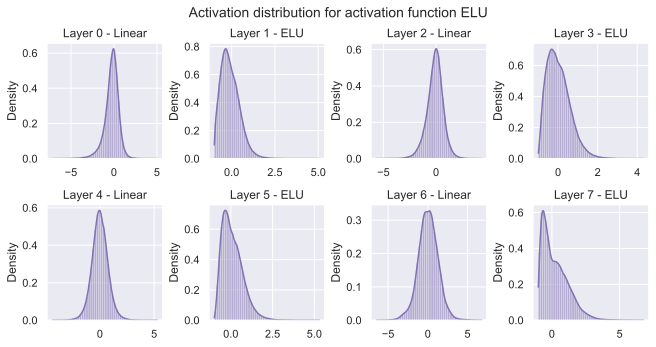

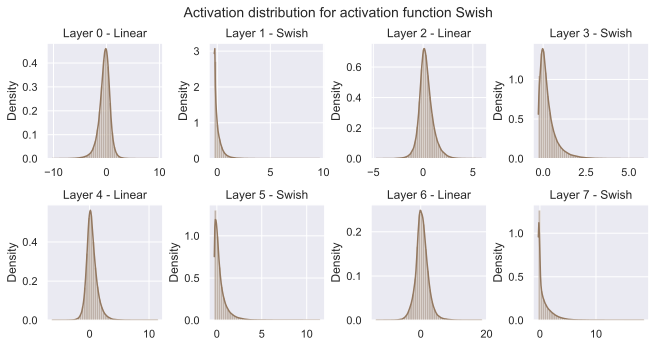

In [21]:
for i, act_fn_name in enumerate(act_fn_by_name):
    net_actfn = load_model(model_path=CHECKPOINT_PATH, model_name=f"FashionMNIST_{act_fn_name}").to(device)
    visualize_activations(net_actfn, color=f"C{i}")

As the model with sigmoid activation was not able to train properly, the activations are also **less informative** and **all gathered around 0.5**(the activation value for `x=0`).

The tanh shows a more **diverse** behavior. While for the **input layer** experience a larger amount of neurons to be **close to -1 and 1**, where the **gradients are close to zero**, the activations in the two consecutive layers are closer to zero. This is probably because the **input layers look for specific features** in the input image, and the consecutive layers combine those together. The activations for the **last layer** are again more **biased** to the **extreme points** because the classification layer can be seen as a weighted average of those values (the gradients push the activations to those extremes).

The ReLU has a strong peak at 0. The effect of **having no gradients for negative values** is that the network **does not have a Gaussian-like distribution after the linear layers**, but **a longer tail towards the positive values**. The LeakyReLU shows a very similar behavior while ELU follows again a more Gaussian-like distribution. The Swish activation seems to lie in between, although it is worth noting that Swish uses significantly higher values than other activation functions (up to 20).

### Finding dead neurons in ReLU networks

One known **drawback** of the ReLU activation is the occurrence of **“dead neurons”**, i.e. **neurons with no gradient for any training input**. The issue of dead neurons is that as no gradient is provided for the layer, we cannot train the parameters of this neuron in the previous layer to obtain output values besides zero. For dead neurons to happen, the output value of a specific neuron of the linear layer before the ReLU has to be **negative** for all input images. Considering the large number of neurons we have in a neural network, it is not unlikely for this to happen.

Dead neurons in an untrained network:

In [26]:
def measure_number_dead_neurons(net):
    neurons_dead = [
        torch.ones(layer.weight.shape[0], device=device, dtype=torch.bool) for layer in net.layers[:-1] if isinstance(layer, nn.Linear)
    ]

    net.eval()
    with torch.no_grad():
        for imgs, labels in tqdm(train_loader, leave=False):
            layer_index = 0
            imgs = imgs.to(device)
            imgs = imgs.view(imgs.size(0), -1)
            for layer in net.layers[:-1]:
                imgs = layer(imgs)
                if isinstance(layer, ActivationFunction):
                    neurons_dead[layer_index] = torch.logical_and(neurons_dead[layer_index], (imgs == 0).all(dim=0))
                    layer_index += 1
    number_neurons_dead = [t.sum().item() for t in neurons_dead]
    print("Number of dead neurons:", number_neurons_dead)
    print("In percentage:", ", ".join([f"{(100.0 * num_dead / tens.shape[0]):4.2f}%" for tens, num_dead in zip(neurons_dead, number_neurons_dead)]))

In [27]:
set_seed(42)
net_relu = BaseNetwork(act_fn=ReLU()).to(device)
measure_number_dead_neurons(net_relu)

  0%|          | 0/49 [00:00<?, ?it/s]

Number of dead neurons: [0, 0, 3, 10]
In percentage: 0.00%, 0.00%, 1.17%, 7.81%


Dead neurons in a trained network:

In [28]:
net_relu = load_model(model_path=CHECKPOINT_PATH, model_name="FashionMNIST_relu").to(device)
measure_number_dead_neurons(net_relu)

  0%|          | 0/49 [00:00<?, ?it/s]

Number of dead neurons: [0, 0, 0, 3]
In percentage: 0.00%, 0.00%, 0.00%, 2.34%


The number of dead neurons indeed **decreased** in the later layers. However, it should be noted that **dead neurons are especially problematic in the input layer**. As the input does not change over epochs (the training set is kept as it is), training the network cannot turn those neurons back active. Still, the input data has usually a sufficiently high standard deviation to reduce the risk of dead neurons.

For a deep network:

In [29]:
set_seed(42)
net_relu = BaseNetwork(act_fn=ReLU(), hidden_sizes=[256, 256, 256, 256, 256, 128, 128, 128, 128, 128]).to(device)
measure_number_dead_neurons(net_relu)

  0%|          | 0/49 [00:00<?, ?it/s]

Number of dead neurons: [0, 0, 7, 27, 89, 60, 58, 61, 72, 56]
In percentage: 0.00%, 0.00%, 2.73%, 10.55%, 34.77%, 46.88%, 45.31%, 47.66%, 56.25%, 43.75%


The number of dead neurons is significantly higher than before which harms the gradient flow especially in the first iterations. Hence, it is **advisible** to use **other nonlinearities** like **Swish** for **very deep networks**.

# Conclusion

* **Sigmoid** tends to **fail** deep neural networks as the highest gradient it provides is 0.25 leading to vanishing gradients in early layers. 
* All **ReLU-based** activation functions have shown to **perform well**, and **besides** the original **ReLU**, **do not have the issue of dead neurons**. 
* When implementing your own neural network, it is **recommended** to **start with a ReLU-based** network and select the specific activation function based on the properties of the network.

## Trouble Shooting

In case the `ImportError` of `IPython.display` occurs, refers to: [Deprecated use of IPython.display.set_matplotlib_formats #1842](https://github.com/scverse/scanpy/issues/1842)